# 03 — Full Pipeline: Baseline → Dataset → GRPO Training

Flusso completo di sviluppo su **Google Colab** con **Unsloth**:

1. **Setup & Imports** — installa dipendenze, verifica GPU
2. **Genera Dataset** — crea il dataset sintetico (5000 samples)
3. **Baseline Evaluation** — valuta il modello base (senza fine-tuning) e logga su wandb
4. **GRPO Training** — addestra il modello con GRPO e logga su wandb
5. **Post-Training Evaluation** — valuta il modello addestrato e confronta con baseline

> **Requisiti:** GPU su Colab (T4 minimo, A100 ideale)

## 1. Setup su Colab

In [1]:
!rm -rf tris
!git clone https://github.com/GiuseppeBellamacina/tris.git
%cd tris
!bash setup.sh

Cloning into 'tris'...
remote: Enumerating objects: 366, done.
remote: Counting objects: 100% (366/366), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 366 (delta 208), reused 273 (delta 115), pack-reused 0 (from 0)
Receiving objects: 100% (366/366), 628.95 KiB | 2.75 MiB/s, done.
Resolving deltas: 100% (208/208), done.
/content/tris
=== Setup GRPO Strict Generation ===

✅ uv già installato

📦 Installazione dipendenze + progetto...
Using Python 3.12.13 environment at: /usr
Resolved 282 packages in 2.24s
Prepared 72 packages in 20.86s
Uninstalled 10 packages in 509ms
Installed 72 packages in 632ms
 + anthropic==0.86.0
 + apache-tvm-ffi==0.1.9
 + astor==0.8.1
 + async-lru==2.3.0
 + bitsandbytes==0.49.2
 + blake3==1.0.8
 + cbor2==5.9.0
 + compressed-tensors==0.13.0
 + cut-cross-entropy==25.1.1
 - datasets==4.0.0
 + datasets==4.3.0
 + depyf==0.20.0
 + diskcache==5.6.3
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi-cli==0.0.24
 + fastapi-cloud-cli==0.15.1
 

## 2. Imports & GPU Check

In [2]:
import os

# vLLM standby mode disabilitata (0): su Colab il runtime forza
# expandable_segments:True nell'allocator CUDA prima dell'avvio del kernel,
# incompatibile con standby mode. Su A100 o runtime custom si può provare "1".
os.environ["UNSLOTH_VLLM_STANDBY"] = "0"

In [3]:
from unsloth import FastLanguageModel

print("Unsloth importato correttamente")

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"VRAM:            {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: Nessuna GPU trovata!")

import transformers
import trl

print(f"transformers: {transformers.__version__}")
print(f"trl:          {trl.__version__}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth importato correttamente
PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
VRAM:            15.6 GB
transformers: 4.57.6
trl:          0.24.0


In [4]:
import wandb

# Login a wandb — la prima volta su Colab chiede l'API key.
# Prendi la tua key da https://wandb.ai/authorize
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cosmico445 (cosmico445-cosmic-inc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
# Entra nella repo se il clone è appena avvenuto e cwd è ancora /content
import os
from pathlib import Path

_tris = Path.cwd() / "tris"
if _tris.is_dir() and (_tris / "pyproject.toml").exists():
    os.chdir(_tris)
    print(f"cd → {_tris}")
else:
    print(f"cwd già corretto: {Path.cwd()}")

cwd già corretto: /content/tris


In [6]:
import os
from pathlib import Path

# Resolve repo root robustly:
# - normal: cwd is already /content/tris → pyproject.toml found immediately
# - restarted kernel: cwd is /content → Colab fallback kicks in
def _find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    # Colab-specific fallback: repo always cloned to /content/tris
    colab_path = Path("/content/tris")
    if colab_path.exists():
        return colab_path
    raise RuntimeError("Repo root non trovato. Esegui prima la cella di setup (git clone).")

ROOT = _find_repo_root()
os.chdir(ROOT)

# Costanti
WANDB_PROJECT = "grpo-strict-generation"
DATASET_PATH = ROOT / "data" / "synthetic"
CONFIG_PATH = ROOT / "experiments" / "configs" / "grpo.yaml"

# Esporta il progetto wandb come env var così il Trainer di HuggingFace
# non cade sul default "huggingface" se deve auto-inizializzare wandb.
os.environ["WANDB_PROJECT"] = WANDB_PROJECT

print(f"Root progetto: {ROOT}")

Root progetto: /content/tris


## 3. Genera Dataset Sintetico

Generiamo un dataset serio con **5000 samples** (3 livelli di difficoltà: simple, medium, hard).

In [7]:
from src.datasets.dataloader import load_synthetic_dataset
from src.datasets.synthetic_dataset import generate_dataset

NUM_SAMPLES = 5000
SEED = 42

if DATASET_PATH.exists():
    print(f"Dataset già presente in {DATASET_PATH}, lo ricarico...")
else:
    print(f"Genero {NUM_SAMPLES} samples (seed={SEED})...")
    ds = generate_dataset(num_samples=NUM_SAMPLES, seed=SEED)
    ds.save_to_disk(str(DATASET_PATH))
    print(f"Dataset salvato in {DATASET_PATH}")

ds = load_synthetic_dataset(str(DATASET_PATH))

for split_name, split_ds in ds.items():
    print(f"  {split_name}: {len(split_ds)} samples")
    # Distribuzione per difficoltà
    diffs = split_ds["difficulty"]
    for d in ["simple", "medium", "hard"]:
        count = sum(1 for x in diffs if x == d)
        print(f"    json/{d}: {count}")

Genero 5000 samples (seed=42)...


Saving the dataset (0/1 shards):   0%|          | 0/4000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset salvato in /content/tris/data/synthetic
  train: 4000 samples
    json/simple: 388
    json/medium: 1218
    json/hard: 2394
  test: 1000 samples
    json/simple: 107
    json/medium: 306
    json/hard: 587


## 4. Baseline Evaluation

Valutiamo il modello **base** (senza fine-tuning) sul test set.
Questo ci dà il punto di partenza per misurare il miglioramento dopo GRPO.

In [8]:
from src.datasets.dataloader import format_prompt_for_model
from src.evaluation.baseline_eval import generate_completions
from src.evaluation.evaluate import compute_detailed_metrics
from src.models.model_loader import load_model_and_tokenizer
from src.utils.config import load_config

config = load_config(str(CONFIG_PATH))

# Carica modello BASE (senza LoRA, senza fast_inference):
# - no "lora" key → no adapters
# - fast_inference=False → no vLLM, no CUDA graph init
# Questo evita il crash del CUDA allocator (use_count > 0) quando
# il modello di training carica vLLM nello stesso processo subito dopo.
base_config = {"model": {**config["model"], "fast_inference": False}}
print(f"Caricamento modello base: {config['model']['name']}")
model, tokenizer = load_model_and_tokenizer(base_config)

Caricamento modello base: TinyLlama/TinyLlama-1.1B-Chat-v1.0
==((====))==  Unsloth 2026.3.17: Fast Llama patching. Transformers: 4.57.6. vLLM: 0.18.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 206efd3d-5e93-4116-bdd2-761228670514)')' thrown while requesting HEAD https://huggingface.co/unslothai/colab/resolve/20f9daee9da18936efa03ad4e1361884c60cca0c/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8b3ba9c7-d933-4488-a3b0-f504a7578ef4)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/unslothai/colab/20f9daee9da18936efa03ad4e1361884c60cca0c/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: cf7e13f0-ab7d-4cfe-8f39-c9f6f6ab8381)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/unslothai/1/7ec782b7604cd9ea0781c23a4270f031650f5617/config.json
Retrying in 1s [Retry 1/5].


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 3094e107-4654-4f33-a0c2-4ecc4d6687fc)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/unsloth/tinyllama-chat-bnb-4bit/effb5dc8248c9270b0db975639c17084417180a7/tokenizer.json
Retrying in 1s [Retry 1/5].


tokenizer.json: 0.00B [00:00, ?B/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 82b24a6e-c051-412c-84c0-5d1316d986ad)')' thrown while requesting HEAD https://huggingface.co/unsloth/tinyllama-chat-bnb-4bit/resolve/main/chat_template.jinja
Retrying in 1s [Retry 1/5].


In [9]:
# Prepara prompt dal test set
test_ds = ds["test"]
MAX_EVAL_SAMPLES = 200  # limita per velocità su Colab
eval_ds = test_ds.select(range(min(MAX_EVAL_SAMPLES, len(test_ds))))

prompts = [format_prompt_for_model(eval_ds[i], tokenizer) for i in range(len(eval_ds))]
task_types = list(eval_ds["task_type"])
difficulties = list(eval_ds["difficulty"])

print(f"Prompts preparati: {len(prompts)}")

# Genera completions
gen_config = {
    "max_new_tokens": 512,
    "temperature": 0.7,
    "top_p": 0.95,
    "do_sample": True,
}

print("Generazione completions baseline...")
baseline_completions = generate_completions(
    model=model,
    tokenizer=tokenizer,
    prompts=prompts,
    generation_config=gen_config,
    num_return_sequences=1,
    batch_size=4,
)
print(f"Completions generate: {len(baseline_completions)}")

Prompts preparati: 200
Generazione completions baseline...


Generating: 100%|██████████| 50/50 [19:53<00:00, 23.87s/it]

Completions generate: 200


In [10]:
# Calcola metriche baseline
first_completions = [comps[0] for comps in baseline_completions]
baseline_metrics = compute_detailed_metrics(first_completions, task_types, difficulties)

print(f"\n{'='*50}")
print(f"BASELINE — {config['model']['name']}")
print(f"{'='*50}")
print(f"Overall Pass@1: {baseline_metrics['overall_pass_rate']:.4f}")
print("\nPer-category breakdown:")
for cat, stats in baseline_metrics["per_category"].items():
    print(f"  {cat}: {stats['pass_rate']:.4f} ({stats['valid']}/{stats['total']})")

# Log su wandb
wandb.init(
    project=WANDB_PROJECT,
    name=f"baseline-{config['model']['name'].split('/')[-1]}",
    tags=["baseline", "notebook-03"],
    config={"model": config["model"], "eval_samples": len(prompts)},
)

wandb_metrics = {"overall_pass_rate": baseline_metrics["overall_pass_rate"]}
for cat, stats in baseline_metrics["per_category"].items():
    wandb_metrics[f"pass_rate/{cat}"] = stats["pass_rate"]
wandb.log(wandb_metrics)

wandb.finish()
print("\nBaseline loggata su wandb")


BASELINE — TinyLlama/TinyLlama-1.1B-Chat-v1.0
Overall Pass@1: 0.5550

Per-category breakdown:
  json/hard: 0.4472 (55/123)
  json/medium: 0.7451 (38/51)
  json/simple: 0.6923 (18/26)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


overall_pass_rate,▁
pass_rate/json/hard,▁
pass_rate/json/medium,▁
pass_rate/json/simple,▁
overall_pass_rate,0.555
pass_rate/json/hard,0.44715
pass_rate/json/medium,0.7451
pass_rate/json/simple,0.69231



Baseline loggata su wandb


In [12]:
# Qualche esempio di completions baseline
from src.training.rewards import combined_reward

print("Esempi di completions baseline:\n")
for i in [0, 1, 5, 10]:
    if i >= len(eval_ds):
        break
    comp = first_completions[i]
    r = combined_reward(comp)
    print(f"--- [{difficulties[i]}] reward={r} ---")
    print(f"Prompt:     {eval_ds[i]['prompt'][:100]}...")
    print(f"Completion: {comp[:200]}")
    print()

Esempi di completions baseline:

--- [hard] reward=0.0 ---
Prompt:     Generate a JSON object representing a database migration plan with 4 operations. Each operation shou...
Completion: ```json
[
  {
    "order": 1,
    "type": "create_table",
    "table": "new_table",
    "definition": {
      "table_name": "new_table",
      "columns": [
        {
          "name": "column_name",
 

--- [hard] reward=0.9 ---
Prompt:     Generate a JSON object representing a database migration plan with 6 operations. Each operation shou...
Completion: ```json
{
  "operations": [
    {
      "order": 1,
      "type": "add_column",
      "table": "my_table",
      "definition": {
        "column": "my_column",
        "type": "integer",
        "not_

--- [hard] reward=0.0 ---
Prompt:     Generate a JSON object representing a database migration plan with 3 operations. Each operation shou...
Completion: ```json
{
  "operations": [
    {
      "order": 1,
      "type": "create_table",
      "table": "my_

In [ ]:
# Libera VRAM dal modello base
del model
torch.cuda.empty_cache()
print("VRAM liberata")

## 5. GRPO Training

Addestriamo il modello con **GRPO** (Group Relative Policy Optimization).
Il config viene letto da `experiments/configs/grpo.yaml`.

Parametri chiave:
- **learning_rate**: 5e-6
- **optim**: paged_adamw_8bit (meno VRAM)
- **max_grad_norm**: 0.1 (gradient clipping aggressivo)
- **num_generations**: 8 (gruppo per calcolare i vantaggi relativi)
- **beta**: 0.04 (KL penalty)

> **fast_inference**: se `true` nel config, usa vLLM interno per generazione 2-5x più veloce.
> Si attiva automaticamente solo su Linux con vLLM installato; altrimenti fallback a `model.generate()`.

> **UNSLOTH_VLLM_STANDBY**: disabilitato su Colab T4 perché il runtime forza
> `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` prima dell'avvio del kernel,
> incompatibile con la standby mode. Su A100 o runtime custom potrebbe funzionare.


In [13]:
from datasets import Dataset
from src.training.rewards import build_reward_function

# Ricarica modello CON LoRA per il training
print(f"Caricamento modello con LoRA: {config['model']['name']}")
model, tokenizer = load_model_and_tokenizer(config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parametri totali:    {total:,}")
print(f"Parametri trainable: {trainable:,} ({100 * trainable / total:.2f}%)")

Caricamento modello con LoRA: TinyLlama/TinyLlama-1.1B-Chat-v1.0
fast_inference abilitato (vLLM backend)
INFO 03-30 11:14:22 [vllm_utils.py:724] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2026.3.17: Fast Llama patching. Transformers: 4.57.6. vLLM: 0.18.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/tinyllama-chat-bnb-4bit with actual GPU utilization = 69.62%
Unsloth: Your GPU has CUDA compute capability 7.5 with VRAM = 14.56 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 2048. Num Sequences = 48.
Unsloth: vLLM's KV Cache can use up to 9.16 GB. Also swap space = 0 GB.
Unsloth: Not an error, b

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

...

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 30/30 [00:39<00:00,  1.30s/it]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 18/18 [00:03<00:00,  5.26it/s]

INFO 03-30 11:22:12 [gpu_model_runner.py:5746] Graph capturing finished in 43 secs, took 0.56 GiB
INFO 03-30 11:22:12 [vllm_utils.py:736] Unsloth: Patched vLLM v1 graph capture finished in 43 secs.


INFO 03-30 11:22:14 [gpu_worker.py:617] CUDA graph pool memory: 0.56 GiB (actual), 0.7 GiB (estimated), difference: 0.14 GiB (25.9%).
INFO 03-30 11:22:14 [core.py:281] init engine (profile, create kv cache, warmup model) took 395.84 seconds
INFO 03-30 11:22:15 [llm.py:391] Supported tasks: ('generate',)
Unsloth: Just some info: will skip parsing ['post_attention_layernorm', 'norm2', 'input_layernorm', 'post_layernorm', 'post_feedforward_layernorm', 'k_norm', 'norm', 'norm1', 'layer_norm2', 'pre_feedforward_layernorm', 'attention_norm', 'ffn_norm', 'q_norm', 'layer_norm1']
Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['post_attention_layernorm', 'norm2', 'input_layernorm', 'post_layernorm', 'post_feedforward_layernorm', 'k_norm', 'norm', 'cross_attn_post_attention_layernorm', 'norm1', 'layer_norm2', 'pre_feedforward_layernorm', 'attention_norm', 'ffn_norm', 'q_norm', 'layer_norm1', 'cross_attn_input_layernorm']


Unsloth 2026.3.17 patched 22 layers with 22 QKV layers, 22 O layers and 22 MLP layers.


Parametri totali:    628,221,952
Parametri trainable: 12,615,680 (2.01%)


In [ ]:
# Prepara dataset di training (prompt formattati)
train_ds = ds["train"]
formatted = []
for i in range(len(train_ds)):
    s = train_ds[i]
    p = format_prompt_for_model(s, tokenizer)
    formatted.append({"prompt": p})

prompt_dataset = Dataset.from_list(formatted)
print(f"Training dataset: {len(prompt_dataset)} prompt pronti")

# Reward function — passa thinking dal config così i pesi si adattano automaticamente
thinking = config.get("dataset", {}).get("thinking", True)
reward_fn = build_reward_function(config["reward"], thinking=thinking)
print(f"Reward function creata (thinking={'on' if thinking else 'off'})")


Training dataset: 4000 prompt pronti
Reward function creata


In [15]:
import datetime

from trl import GRPOConfig

training_cfg = config["training"]
grpo_cfg = config["grpo"]

output_dir = str(ROOT / "experiments" / "checkpoints" / "grpo_full")
log_dir = str(ROOT / "experiments" / "logs" / "grpo_full")
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(log_dir).mkdir(parents=True, exist_ok=True)

_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"grpo-full-{_ts}"

# bf16 vs fp16 in base alla GPU
_supports_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
use_bf16 = _supports_bf16
use_fp16 = not _supports_bf16 and torch.cuda.is_available()

grpo_config = GRPOConfig(
    output_dir=output_dir,
    run_name=run_name,
    # Training
    max_steps=training_cfg.get("max_steps", 1000),
    per_device_train_batch_size=training_cfg.get("per_device_train_batch_size", 1),
    gradient_accumulation_steps=training_cfg.get("gradient_accumulation_steps", 8),
    learning_rate=training_cfg.get("learning_rate", 5e-6),
    lr_scheduler_type=training_cfg.get("lr_scheduler_type", "cosine"),
    warmup_ratio=training_cfg.get("warmup_ratio", 0.1),
    optim=training_cfg.get("optim", "paged_adamw_8bit"),
    weight_decay=training_cfg.get("weight_decay", 0.1),
    max_grad_norm=training_cfg.get("max_grad_norm", 0.1),
    bf16=use_bf16,
    fp16=use_fp16,
    # GRPO
    num_generations=grpo_cfg.get("num_generations", 8),
    max_completion_length=grpo_cfg.get("max_completion_length", 512),
    max_prompt_length=grpo_cfg.get("max_prompt_length", 256),
    beta=grpo_cfg.get("beta", 0.04),
    temperature=grpo_cfg.get("temperature", 0.7),
    # Logging
    logging_dir=log_dir,
    logging_steps=training_cfg.get("logging_steps", 10),
    save_steps=training_cfg.get("save_steps", 200),
    save_total_limit=training_cfg.get("save_total_limit", 3),
    report_to="wandb",
)

# Inizializza il run wandb PRIMA del trainer, così il GRPOTrainer
# riusa il run attivo anziché crearne uno con project="huggingface".
wandb.init(
    project=WANDB_PROJECT,
    name=run_name,
    tags=["grpo", "notebook-03", config["model"]["name"].split("/")[-1]],
    config=config,
)

print("GRPOConfig creata")
print(f"  run_name:       {grpo_config.run_name}")
print(f"  max_steps:      {grpo_config.max_steps}")
print(f"  num_generations: {grpo_config.num_generations}")
print(f"  batch_size:     {grpo_config.per_device_train_batch_size}")
print(f"  grad_accum:     {grpo_config.gradient_accumulation_steps}")
print(f"  learning_rate:  {grpo_config.learning_rate}")
print(f"  optim:          {grpo_config.optim}")
print(f"  beta:           {grpo_config.beta}")
print(f"  bf16={use_bf16}, fp16={use_fp16}")

GRPOConfig creata
  run_name:       grpo-full-20260330_112220
  max_steps:      300
  num_generations: 8
  batch_size:     1
  grad_accum:     8
  learning_rate:  5e-06
  optim:          OptimizerNames.PAGED_ADAMW_8BIT
  beta:           0.04
  bf16=False, fp16=True


In [16]:
from trl import GRPOTrainer

trainer = GRPOTrainer(
    model=model,
    args=grpo_config,
    train_dataset=prompt_dataset,
    reward_funcs=reward_fn,
    processing_class=tokenizer,
)

print(f"Trainer inizializzato (tipo: {type(trainer).__name__})")
print(f"\nAvvio GRPO training ({grpo_config.max_steps} step)...\n")

trainer.train()
print("\nTraining completato!")

Trainer inizializzato (tipo: UnslothGRPOTrainer)

Avvio GRPO training (300 step)...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,000 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)


WARNING 03-30 11:22:24 [input_processor.py:141] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,-0.000000,0.353655,0.253656,367.125000,257.400000,473.800000,0.425000,251.128574,155.000000,332.000000,0.000007,0.353655,0.253656
10,-0.000000,0.540069,0.339538,286.550000,224.600000,357.000000,0.325000,265.675000,224.600000,335.400000,0.000004,0.540069,0.339538
15,-0.000000,0.644833,0.250007,329.075000,154.400000,403.400000,0.375000,266.625000,154.400000,388.800000,0.000005,0.644833,0.250007
20,0.000000,0.321486,0.351415,478.075000,343.600000,512.000000,0.825000,258.400000,241.200000,275.600000,0.000005,0.321486,0.351415
25,-0.000000,0.464562,0.363596,404.275000,237.400000,512.000000,0.450000,339.121436,237.400000,435.400000,0.000006,0.464562,0.363596
30,-0.000000,0.418589,0.321852,409.000000,317.600000,495.000000,0.550000,161.932147,112.800000,241.200000,0.000007,0.418589,0.321852
35,0.000000,0.391482,0.280160,342.775000,238.600000,512.000000,0.450000,203.685718,136.200000,272.600000,0.000010,0.391482,0.280160
40,0.000000,0.652917,0.202821,215.300000,152.400000,313.000000,0.175000,208.125000,152.400000,304.800000,0.000017,0.652917,0.202821
45,0.000000,0.374631,0.242599,439.175000,338.400000,512.000000,0.625000,292.240002,236.000000,346.200000,0.000016,0.374631,0.242599
50,0.000100,0.626278,0.204889,310.575000,206.000000,428.200000,0.325000,261.275000,206.000000,377.200000,0.000025,0.626278,0.204889



Training completato!


In [17]:
# Salva il modello finale
final_path = Path(output_dir) / "final"
trainer.save_model(str(final_path))
tokenizer.save_pretrained(str(final_path))
print(f"Modello salvato in {final_path}")

# Chiudi il run wandb del training prima di aprirne uno nuovo per l'eval
wandb.finish()
print("Run wandb training chiuso")

Modello salvato in /content/tris/experiments/checkpoints/grpo_full/final


profiling/Time taken: UnslothGRPOTrainer._calculate_rewards,▂▆▃▄▁▂▂▅▃▂▄▅▂▂▃▂▂▂▄▂▂▂█▁▃▄▃▃▃▂▂▃▂▂▄▄▄▃▅▂
profiling/Time taken: UnslothGRPOTrainer._prepare_inputs,▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▁▁▁▁▁▁▁▁▁▁▁▇▁▁▁▁▁▁▁
profiling/Time taken: UnslothGRPOTrainer.reward_fn,▄▂▂▁▅▁▂▄▃▃▃▁▂▂▂▅▄▄▂▂▂▆█▂▃▁▅▂▇▅▇▂▃▃▅▆▆▃▁▆
profiling/Time taken: UnslothGRPOTrainer.vLLM.generate,██▁████▃▆█▂▆█▃█████▂██▇███▃███▄▁▃▂▂███▃█
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_min,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/region_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/completion_length,▅▄█▆▄▇▄▁▄▅▃▄▃▃▆▃▆▄▄▆▃▇▅▅▆▇▄▁▇▄▁▄▄█▆▃▂▄▃▆
+19,...


Run wandb training chiuso


## 6. Post-Training Evaluation

Valutiamo il modello addestrato sullo **stesso test set** usato per la baseline.

In [18]:
# Genera completions con il modello trainato
# Usiamo gli stessi prompt della baseline per un confronto diretto
print("Generazione completions post-GRPO...")
grpo_completions = generate_completions(
    model=model,
    tokenizer=tokenizer,
    prompts=prompts,
    generation_config=gen_config,
    num_return_sequences=1,
    batch_size=4,
)

# Calcola metriche post-GRPO
grpo_first = [comps[0] for comps in grpo_completions]
grpo_metrics = compute_detailed_metrics(grpo_first, task_types, difficulties)

print(f"\n{'='*50}")
print(f"POST-GRPO — {config['model']['name']}")
print(f"{'='*50}")
print(f"Overall Pass@1: {grpo_metrics['overall_pass_rate']:.4f}")
print("\nPer-category breakdown:")
for cat, stats in grpo_metrics["per_category"].items():
    print(f"  {cat}: {stats['pass_rate']:.4f} ({stats['valid']}/{stats['total']})")

# Log su wandb
wandb.init(
    project=WANDB_PROJECT,
    name=f"grpo-eval-{config['model']['name'].split('/')[-1]}",
    tags=["grpo-eval", "notebook-03"],
    config=config,
)

grpo_wandb = {"overall_pass_rate": grpo_metrics["overall_pass_rate"]}
for cat, stats in grpo_metrics["per_category"].items():
    grpo_wandb[f"pass_rate/{cat}"] = stats["pass_rate"]
wandb.log(grpo_wandb)

wandb.finish()
print("\nMetriche post-GRPO loggate su wandb")

Generazione completions post-GRPO...


Generating: 100%|██████████| 50/50 [28:34<00:00, 34.29s/it]



POST-GRPO — TinyLlama/TinyLlama-1.1B-Chat-v1.0
Overall Pass@1: 0.6950

Per-category breakdown:
  json/hard: 0.6016 (74/123)
  json/medium: 0.7843 (40/51)
  json/simple: 0.9615 (25/26)


overall_pass_rate,▁
pass_rate/json/hard,▁
pass_rate/json/medium,▁
pass_rate/json/simple,▁
overall_pass_rate,0.695
pass_rate/json/hard,0.60163
pass_rate/json/medium,0.78431
pass_rate/json/simple,0.96154



Metriche post-GRPO loggate su wandb


## 7. Confronto Baseline vs GRPO

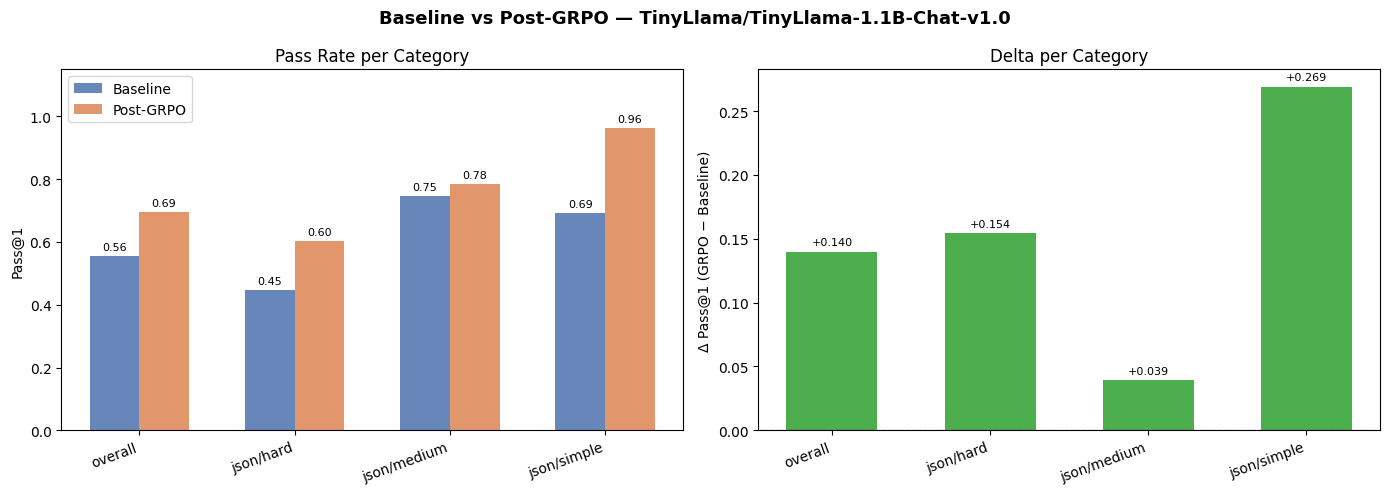


Categoria                        Baseline  Post-GRPO      Delta
--------------------------------------------------------------
  overall                          0.5550     0.6950    +0.1400
  json/hard                        0.4472     0.6016    +0.1545
  json/medium                      0.7451     0.7843    +0.0392
  json/simple                      0.6923     0.9615    +0.2692

GRPO ha migliorato il pass rate di +0.1400 (+25.2%)


In [19]:
import matplotlib.pyplot as plt
import numpy as np

all_cats = sorted(set(
    list(baseline_metrics["per_category"].keys()) +
    list(grpo_metrics["per_category"].keys())
))
labels = ["overall"] + all_cats
b_values = [baseline_metrics["overall_pass_rate"]] + [
    baseline_metrics["per_category"].get(c, {}).get("pass_rate", 0.0) for c in all_cats
]
g_values = [grpo_metrics["overall_pass_rate"]] + [
    grpo_metrics["per_category"].get(c, {}).get("pass_rate", 0.0) for c in all_cats
]
deltas = [g - b for g, b in zip(g_values, b_values)]

x = np.arange(len(labels))
width = 0.32

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Baseline vs Post-GRPO — {config['model']['name']}", fontsize=13, fontweight="bold")

# ── Grouped bar: pass rate per categoria ──────────────────────────────────────
ax = axes[0]
bars_b = ax.bar(x - width / 2, b_values, width, label="Baseline", color="#4C72B0", alpha=0.85)
bars_g = ax.bar(x + width / 2, g_values, width, label="Post-GRPO", color="#DD8452", alpha=0.85)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Pass@1")
ax.set_title("Pass Rate per Category")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.legend()
ax.bar_label(bars_b, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(bars_g, fmt="%.2f", padding=3, fontsize=8)
ax.axhline(0, color="black", linewidth=0.5)

# ── Delta bar: miglioramento per categoria ────────────────────────────────────
ax2 = axes[1]
colors = ["#2ca02c" if d >= 0 else "#d62728" for d in deltas]
bars_d = ax2.bar(x, deltas, width * 1.8, color=colors, alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Δ Pass@1 (GRPO − Baseline)")
ax2.set_title("Delta per Category")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=20, ha="right")
ax2.bar_label(bars_d, fmt="%+.3f", padding=3, fontsize=8)

fig.tight_layout()
plt.show()

# Tabella testuale di riepilogo
print(f"\n{'Categoria':<30} {'Baseline':>10} {'Post-GRPO':>10} {'Delta':>10}")
print("-" * 62)
for lbl, b, g, d in zip(labels, b_values, g_values, deltas):
    print(f"  {lbl:<28} {b:>10.4f} {g:>10.4f} {d:>+10.4f}")
delta_overall = g_values[0] - b_values[0]
print()
if delta_overall > 0:
    print(f"GRPO ha migliorato il pass rate di {delta_overall:+.4f} ({delta_overall / max(b_values[0], 1e-6) * 100:+.1f}%)")
elif delta_overall < 0:
    print(f"GRPO ha peggiorato il pass rate di {delta_overall:.4f}")
else:
    print("Nessun cambiamento")


In [21]:
# Qualche esempio di completions post-GRPO
print("Esempi di completions post-GRPO:\n")
for i in [0, 1, 5, 10]:
    if i >= len(eval_ds):
        break
    comp = grpo_first[i]
    r = combined_reward(comp)
    print(f"--- [{difficulties[i]}] reward={r} ---")
    print(f"Prompt:     {eval_ds[i]['prompt'][:100]}...")
    print(f"Completion: {comp[:200]}")
    print()

Esempi di completions post-GRPO:

--- [hard] reward=0.9 ---
Prompt:     Generate a JSON object representing a database migration plan with 4 operations. Each operation shou...
Completion: ```json
{
  "operations": [
    {
      "order": 1,
      "type": "create_table",
      "table": "new_table",
      "definition": {
        "columns": [
          {
            "name": "id",
         

--- [hard] reward=0.0 ---
Prompt:     Generate a JSON object representing a database migration plan with 6 operations. Each operation shou...
Completion: ```json
{
  "operations": [
    {
      "order": 1,
      "type": "create_table",
      "table": "new_table",
      "definition": {
        "columns": [
          {
            "name": "id",
         

--- [hard] reward=0.0 ---
Prompt:     Generate a JSON object representing a database migration plan with 3 operations. Each operation shou...
Completion: ```json
{
  "operations": [
    {
      "order": 1,
      "type": "create_table",
      "table": "my

In [22]:
# Pulizia VRAM
del trainer
del model
torch.cuda.empty_cache()
print("VRAM liberata")

VRAM liberata


## Riepilogo

Questo notebook ha eseguito il flusso completo:

1. **Dataset** — 5000 samples JSON (simple/medium/hard)
2. **Baseline** — valutazione modello base → metriche su wandb
3. **GRPO Training** — addestramento con reward rule-based → loss/reward su wandb
4. **Post-GRPO** — valutazione modello trainato → confronto con baseline

Tutti i run sono su **wandb** sotto il progetto `grpo-strict-generation`.

**Comandi CLI equivalenti:**
```bash
# Baseline
uv run python -m src.evaluation.baseline_eval --config experiments/configs/baseline.yaml

# GRPO Training
uv run python -m src.training.grpo_train --config experiments/configs/grpo.yaml
```